In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycontrails import Fleet

In [2]:
# EGWP 100
dff = pd.read_parquet("../data/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)

dfo = pd.read_parquet("../data/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
target = "EGWP100"

In [6]:
# EGWP 20
dff = pd.read_parquet("../data/filed_trajectories_EAGWP20.parquet")
fleetf = Fleet(data=dff)

dfo = pd.read_parquet("../data/optimised_trajectories_EAGWP20.parquet")
fleeto = Fleet(data=dfo)
target = "EGWP20"

In [10]:
# ATR 100
dff = pd.read_parquet("../data/filed_trajectories_ATR100.parquet")
fleetf = Fleet(data=dff)

dfo = pd.read_parquet("../data/optimised_trajectories_ATR100.parquet")
fleeto = Fleet(data=dfo)
target = "ATR100"

In [11]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["NOx", "O3", "CH4", "H2O"])
mask_by_marker(fleeto, ["NOx", "O3", "CH4", "H2O"])

from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["NOx", "O3", "CH4", "H2O"], bounds)
mask_by_validity_range(fleeto, ["NOx", "O3", "CH4", "H2O"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O


In [12]:
cols = [
    'CO2', 'CO2_with_aCCF', 'CoCiP', 'CiC',
    'NOx', 'O3', 'CH4', 'H2O',
]

tmp = fleetf.dataframe[["flight_id"] + cols].groupby("flight_id").sum().reset_index()
plotme = tmp[cols].sum().rename(target) / fleetf.dataframe.flight_id.nunique() / 1e3

tmp2 = fleeto.dataframe[["flight_id"] + cols].groupby("flight_id").sum().reset_index()
plotme2 = tmp2[cols].sum().rename(target) / fleeto.dataframe.flight_id.nunique() / 1e3

In [5]:
egwp100 = plotme.copy()
egwp100o = plotme2.copy()

In [9]:
egwp20 = plotme.copy()
egwp20o = plotme2.copy()

In [13]:
atr100 = plotme.copy()
atr100o = plotme2.copy()

In [14]:
def get_df_percent(dfs):
    df = pd.concat(dfs, axis=1)
    order = ["CO2", "CoCiP", "NOx", "H2O"]
    df = df.loc[order]
    # Normalize columns to percentages
    df_percent = df.div(df.sum(axis=0), axis=1) * 100
    return df_percent


df_percentf = get_df_percent([egwp100, atr100, egwp20])
df_percento = get_df_percent([egwp100o, atr100o, egwp20o])

In [15]:
lee2021 = pd.DataFrame(data={
    "RF": [34.3, 111.4, 8.2, 2.0],
    "ERF": [34.3, 57.4, 17.5, 2.0],
    "GWP100": [1034, 652, 163, 23],
    # "EGWP100": [1034 * 1, 652 * 0.21, 163 * 1.045, 23 * 1],
    # "EGWP100_v2": [1034 * 1, 652 * 0.9, 163 * 1.045, 23 * 1],
    "GWP20": [1034, 2399, 887, 83],
    # "EGWP20": [1034 * 1, 2399 * 0.21, 887 * 1.045, 83 * 1],
    # "ERF_CI": [(28, 40), (17, 98), (0.6, 29), (0.8, 3.2)]
}, index=["CO2", "Contrails", "NOx", "H2O"])

# Normalize columns to percentages
lee_percent = lee2021.div(lee2021.sum(axis=0), axis=1) * 100

In [16]:
dfs = [df_percentf, df_percento, lee_percent[["GWP100", "GWP20"]]] # do not use EGWP100 for Lee

In [29]:
# for v, (low, high) in zip(lee2021["ERF"].values, lee2021["ERF_CI"].values):
#     pct_down = (v - low) / v * 100
#     pct_up = (high - v) / v * 100
#     print(f"value={v}: -{pct_down:.1f}% / +{pct_up:.1f}%")

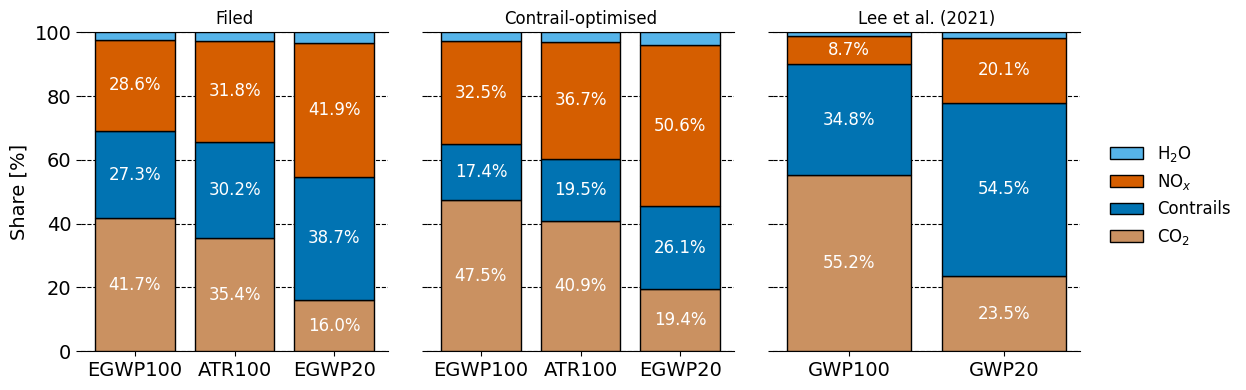

In [17]:
species_with_subscripts = {
    "CO2": "CO$_2$",
    "CoCiP": "Contrails",
    "Contrails": "Contrails",
    "NOx": "NO$_x$",
    "H2O": "H$_2$O",
}
from cane.colors import colors, sns_idx

colors_by_species = {
    "CO2": colors[sns_idx["brown"]],
    "CoCiP": colors[sns_idx["darkblue"]],
    "Contrails": colors[sns_idx["darkblue"]],
    "NOx": colors[sns_idx["red"]],
    "H2O": colors[sns_idx["lightblue"]]
}

# X positions for the bars
x = np.arange(len(df_percentf.columns))
bar_width = 0.8

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)

for ax, df_tmp in zip(axes, dfs):
    # X positions
    x = np.arange(len(df_tmp.columns))
    bar_width = 0.8
    bottoms = np.zeros(len(df_tmp.columns))

    new_labels = [species_with_subscripts[c] for c in df_tmp.index]
    colors = [colors_by_species[c] for c in df_tmp.index]

    # Stacked bars
    for i, row in enumerate(df_tmp.values):
        ax.bar(
            x,
            row,
            bottom=bottoms,
            color=colors[i],
            edgecolor="black",
            width=bar_width,
            label=new_labels[i],
            zorder=10,
        )

        # percentage labels
        for j, val in enumerate(row):
            if val > 4:
                # if ax == axes[2] and j == 0:
                #     # ERF
                #     pct_down = (val - lee2021["ERF_CI"].values[i][0]) / val * 100
                #     print(val, i)
                #     ax.text(
                #         x[j], bottoms[j] + val / 2, f"{val:.1f}%\n[{pct_down:.0f}]",
                #         ha='center', va='center',
                #         color='white', fontsize=12,
                #         zorder=15
                #     )
                # else:
                ax.text(
                    x[j], bottoms[j] + val / 2, f"{val:.1f}%",
                    ha='center', va='center',
                    color='white', fontsize=12,
                    zorder=15
                )

        bottoms += row

    # Formatting (same as yours)
    ax.set_xticks(x)
    ax.set_xticklabels(df_tmp.columns, fontsize=14)
    ax.set_ylim([0, 100])
    ax.tick_params(axis='y', labelsize=14)

    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.grid(axis='y', color="black", linestyle="--", zorder=0)

# shared y-label (only once)
axes[0].set_ylabel("Share [%]", fontsize=14)
axes[0].set_title("Filed")
axes[1].set_title("Contrail-optimised")
axes[2].set_title("Lee et al. (2021)")# + efficacy")

# ---- shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles[::-1], labels[::-1],
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=12,
    edgecolor='none'
)

fig.subplots_adjust(wspace=0.8)

plt.tight_layout()
plt.savefig("./figures/fig10.png", dpi=300, bbox_inches='tight')  # when EGWP100 for CO2 is 49%, it is filed

In [5]:
# July 8
def delta(before: float, after: float) -> float:
    # in %
    if before == 0:
        raise ValueError("'before' cannot be zero — percent change is undefined.")
    return round((after - before) / before * 100, 1)

In [ ]:
# textual description (%)
print("CO2 GWP100:", delta(55.2, 41.7), delta(55.2, 47.5))
print("Contrail GWP100:", delta(34.8, 27.3), delta(34.8, 17.4))
print("NOx GWP100:", delta(8.7, 28.6), delta(8.7, 32.5))

print(">>>")
print("CO2 GWP20:", delta(23.5, 16), delta(23.5, 19.4))
print("Contrail GWP20:", delta(54.5, 38.7), delta(54.5, 26.1))
print("NOx GWP20:", delta(20.1, 41.9), delta(20.1, 50.6))

CO2 GWP100: -24.5 -13.9
Contrail GWP100: -21.6 -50.0
NOx GWP100: 228.7 273.6
>>>
CO2 GWP20: -31.9 -17.4
Contrail GWP20: -29.0 -52.1
NOx GWP20: 108.5 151.7


In [19]:
# textual description (absolute)
print("CO2 GWP100:", 55.2 - 41.7, 55.2 - 47.5)
print("CO2 GWP20:", 23.5 - 16, 23.5 - 19.4)

print("Contrail GWP100:", 34.8 - 27.3, 34.8 - 17.4)
print("Contrail GWP20:", 54.5 - 38.7, 54.5 - 26.1)

CO2 GWP100: 13.5 7.700000000000003
CO2 GWP20: 7.5 4.100000000000001
Contrail GWP100: 7.4999999999999964 17.4
Contrail GWP20: 15.799999999999997 28.4
